# 01 — Data Exploration & Training-Format Conversion

**Goal:** Load the combined HST grism simulation HDF5, sanity-check the data, then
interpolate every spectrum onto a uniform 7781-pixel grid and save the result as a
wide-format pickle file ready for SpecPT training.

**Datasets read from `/track_a/` in the source HDF5:**

```
grism_id, redshift, flam, cont, wave, ferr, z_quality, snr_median
```

**Derived per-spectrum column:** `line_peak_snr = max((flam - cont) / ferr)`.
This replaces `snr_median` as the primary SNR metric — `snr_median` is robust to
bright emission lines, while `line_peak_snr` directly measures line strength.

**Output:** `data/training_format/grism_training_sim_v1.pkl`

Long format: one row per `(grism_id, wavelength_pixel)` pair.
Output columns: `grism_id, wavelength, flux, z, line_peak_snr, continuum_sub_flux`.

The 7781-pixel target matches `configs/defaults.yaml` (`input_size: 7781`), so the
output is directly compatible with the existing SpecPT model.


In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
from pathlib import Path

tqdm.pandas()

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})


## 1. Configuration

Point `SRC` at the combined HDF5 file. `TRACK` selects which grism to read from.
`OUT` is the wide-format pickle target.
Quality cuts are applied immediately after loading (cell 6):
`LINE_PEAK_SNR_MIN`, `LINE_PEAK_SNR_MAX`, and `Z_QUALITY_MIN`.


In [3]:
SRC = Path(r"F:\personal_projects\HST_GRISM_Sim\output\hst_grism_combined.h5")
OUT = Path(r"F:\personal_projects\specpt-hst-sim\data\training_format\grism_training_sim_v1.pkl")
TRACK = "track_a"
N_PIXELS = 7781

# --- Wavelength trimming: mask noisy detector edges ---
WAVE_TRIM_ENABLED = True
WAVE_MIN = 11000  # Angstroms - blue edge cutoff (G141 reliable range starts ~10750)
WAVE_MAX = 16500  # Angstroms - red edge cutoff (G141 reliable range ends ~17000)

OUT.parent.mkdir(parents=True, exist_ok=True)

# --- Filter placeholders (leave None to skip that filter) ---
LINE_PEAK_SNR_MIN = 2.5   # remove spectra with no detectable line
LINE_PEAK_SNR_MAX = 15   # remove spectra with unrealistically bright lines
Z_QUALITY_MIN = None       # e.g. 1  -> df = df[df['z_quality_a'] >= Z_QUALITY_MIN]

print(f"Source : {SRC}")
print(f"Group  : /{TRACK}/")
print(f"Output : {OUT}")
print(f"N_PIXELS: {N_PIXELS}")
print(f"Wavelength trim: {WAVE_TRIM_ENABLED} ({WAVE_MIN}-{WAVE_MAX} A)")
print(f"line_peak_snr range filter: {LINE_PEAK_SNR_MIN} \u2013 {LINE_PEAK_SNR_MAX}")


Source : F:\personal_projects\HST_GRISM_Sim\output\hst_grism_combined.h5
Group  : /track_a/
Output : F:\personal_projects\specpt-hst-sim\data\training_format\grism_training_sim_v1.pkl
N_PIXELS: 7781
Wavelength trim: True (11000-16500 A)
line_peak_snr range filter: 2.5 – 15


In [4]:
def trim_wavelength_range(wavelengths, flux, wave_min, wave_max):
    """
    Mask pixels outside the reliable G141 wavelength range by setting to NaN.
    
    Parameters
    ----------
    wavelengths : array-like
        Wavelength array in Angstroms
    flux : array-like  
        Flux array (same shape as wavelengths)
    wave_min : float
        Minimum wavelength to keep (A)
    wave_max : float
        Maximum wavelength to keep (A)
    
    Returns
    -------
    trimmed_flux : ndarray
        Flux with out-of-range pixels set to NaN
    """
    wavelengths = np.asarray(wavelengths)
    flux = np.asarray(flux, dtype=float)
    trimmed_flux = flux.copy()
    mask = (wavelengths < wave_min) | (wavelengths > wave_max)
    trimmed_flux[mask] = np.nan
    return trimmed_flux


## 2. Load + build `master_data`

Read the HDF5 file and build a DataFrame with the 7 target columns. The spectral
arrays (`flam`, `cont`, `wave`) live under `/track_a/` as 2D arrays of
shape (N_spectra, 312). We alias the dataset names to match the notebook's
convention (`track_a_flam`, `track_a_cont`, `wave_a`, `z_quality_a`, `snr_median_track_a`).


In [5]:
with h5py.File(SRC, 'r') as f:
    g = f[TRACK]
    n_spec = g['redshift'].shape[0]
    print(f"Source : {SRC}  (group=/{TRACK}/,  {n_spec:,} spectra)")
    grism_id  = [x.decode() if isinstance(x, bytes) else x for x in g['grism_id'][:]]
    redshift  = g['redshift'][:].astype(np.float32)
    z_quality = g['z_quality'][:].astype(np.int8)
    snr_med   = g['snr_median'][:].astype(np.float32)
    flam_2d   = g['flam'][:]
    cont_2d   = g['cont'][:]
    ferr_2d   = g['ferr'][:]
    wave      = list(g['wave'][:])

# Derive line_peak_snr = max((flam - cont) / ferr) per spectrum.
# Median SNR is robust to a single bright pixel, so it can be 1.8 even when a strong
# emission line is present. line_peak_snr is the actual signal strength of the strongest line.
ratio = (flam_2d - cont_2d) / np.where(ferr_2d > 0, ferr_2d, np.inf)
line_peak_snr = ratio.max(axis=1).astype(np.float32)
del ratio, ferr_2d  # free memory
print(f"line_peak_snr summary: min={line_peak_snr.min():.2f}  median={np.median(line_peak_snr):.2f}  max={line_peak_snr.max():.2f}")

flam = list(flam_2d)
cont = list(cont_2d)
del flam_2d, cont_2d

master_data = pd.DataFrame({
    'grism_id':            grism_id,
    'redshift':            redshift,
    'track_a_flam':        flam,
    'track_a_cont':        cont,
    'z_quality_a':         z_quality,
    'snr_median_track_a':  snr_med,
    'wave_a':              wave,
    'line_peak_snr':       line_peak_snr,
})

print(f"master_data shape: {master_data.shape}")
print(f"\nDtypes:")
print(master_data.dtypes)
print(f"\nNaN counts (scalar columns):")
print(master_data[['redshift','z_quality_a','snr_median_track_a','line_peak_snr']].isna().sum())
print(f"\nFirst 3 rows (spectral cols truncated):")
with pd.option_context('display.max_colwidth', 60):
    print(master_data.head(3))


Source : F:\personal_projects\HST_GRISM_Sim\output\hst_grism_combined.h5  (group=/track_a/,  100,000 spectra)
line_peak_snr summary: min=1.82  median=3.10  max=14.99
master_data shape: (100000, 8)

Dtypes:
grism_id                  str
redshift              float32
track_a_flam           object
track_a_cont           object
z_quality_a              int8
snr_median_track_a    float32
wave_a                 object
line_peak_snr         float32
dtype: object

NaN counts (scalar columns):
redshift              0
z_quality_a           0
snr_median_track_a    0
line_peak_snr         0
dtype: int64

First 3 rows (spectral cols truncated):
          grism_id  redshift  \
0  sim-G141-000001  3.141033   
1  sim-G141-000002  3.462672   
2  sim-G141-000003  2.849998   

                                                  track_a_flam  \
0  [1.4751473e-16, 1.09712095e-16, 1.1874006e-16, 1.31574e-...   
1  [4.98006e-16, 4.2408875e-16, 4.740837e-16, 3.5409757e-16...   
2  [9.470996e-16, 1.0501171e-15, 

In [6]:
# Apply quality cuts before interpolation or analysis
filtered = False
if LINE_PEAK_SNR_MIN is not None:
    before = len(master_data)
    master_data = master_data[master_data['line_peak_snr'] >= LINE_PEAK_SNR_MIN].reset_index(drop=True)
    print(f"Filtered on line_peak_snr >= {LINE_PEAK_SNR_MIN}: {before} -> {len(master_data)} spectra")
    filtered = True
if LINE_PEAK_SNR_MAX is not None:
    before = len(master_data)
    master_data = master_data[master_data['line_peak_snr'] <= LINE_PEAK_SNR_MAX].reset_index(drop=True)
    print(f"Filtered on line_peak_snr <= {LINE_PEAK_SNR_MAX}: {before} -> {len(master_data)} spectra")
    filtered = True
if Z_QUALITY_MIN is not None:
    before = len(master_data)
    master_data = master_data[master_data['z_quality_a'] >= Z_QUALITY_MIN].reset_index(drop=True)
    print(f"Filtered on z_quality_a >= {Z_QUALITY_MIN}: {before} -> {len(master_data)} spectra")
    filtered = True
if not filtered:
    print("No quality cuts applied.")


Filtered on line_peak_snr >= 2.5: 100000 -> 92376 spectra
Filtered on line_peak_snr <= 15: 92376 -> 92376 spectra


## 3. Redshift distribution

Overall distribution plus a breakdown by `z_quality_a` flag (3D-HST convention:
`+1` reliable, `0` questionable, `-1` unreliable).


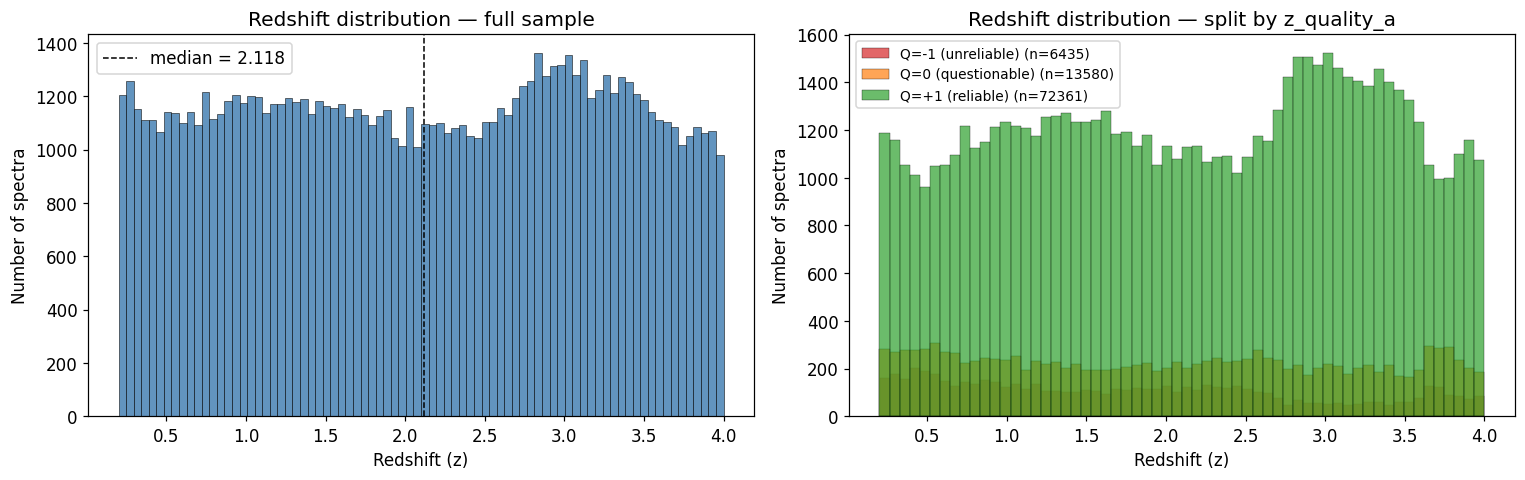

Redshift summary stats:
count    92376.000000
mean         2.103100
std          1.093681
min          0.200022
1%           0.236673
5%           0.385708
50%          2.117705
95%          3.790823
99%          3.954893
max          3.999955

Unique z_quality_a values: [-1, 0, 1]
z_quality_a
-1     6435
 0    13580
 1    72361


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Overall histogram + KDE
axes[0].hist(master_data['redshift'], bins=80, color='steelblue',
             edgecolor='k', lw=0.4, alpha=0.85)
axes[0].axvline(master_data['redshift'].median(), color='k', ls='--', lw=1,
                label=f"median = {master_data['redshift'].median():.3f}")
axes[0].set_xlabel("Redshift (z)")
axes[0].set_ylabel("Number of spectra")
axes[0].set_title("Redshift distribution — full sample")
axes[0].legend()

# Stacked by z_quality_a
zq_vals = [-1, 0, 1]
zq_colors = {1: '#2ca02c', 0: '#ff7f0e', -1: '#d62728'}
zq_labels = {1: 'Q=+1 (reliable)', 0: 'Q=0 (questionable)', -1: 'Q=-1 (unreliable)'}
for zq in zq_vals:
    sub = master_data.loc[master_data['z_quality_a'] == zq, 'redshift']
    axes[1].hist(sub, bins=60, color=zq_colors[zq],
                 edgecolor='k', lw=0.3, alpha=0.7, label=f"{zq_labels[zq]} (n={len(sub)})")
axes[1].set_xlabel("Redshift (z)")
axes[1].set_ylabel("Number of spectra")
axes[1].set_title("Redshift distribution — split by z_quality_a")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

z = master_data['redshift']
print("Redshift summary stats:")
print(z.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_string())
print(f"\nUnique z_quality_a values: {sorted(master_data['z_quality_a'].dropna().unique().tolist())}")
print(master_data['z_quality_a'].value_counts(dropna=False).sort_index().to_string())


## 4. Line SNR analysis

Distribution of `line_peak_snr` on a log scale. This is the peak per-pixel signal-to-noise
ratio of the strongest emission line in each spectrum, computed as
`max((flam - cont) / ferr)` across the 312 native pixels. Unlike `snr_median_track_a`
(a robust median that hides bright lines), `line_peak_snr` directly captures the
line strength. Also a `z` vs `line_peak_snr` scatter to check for selection bias.


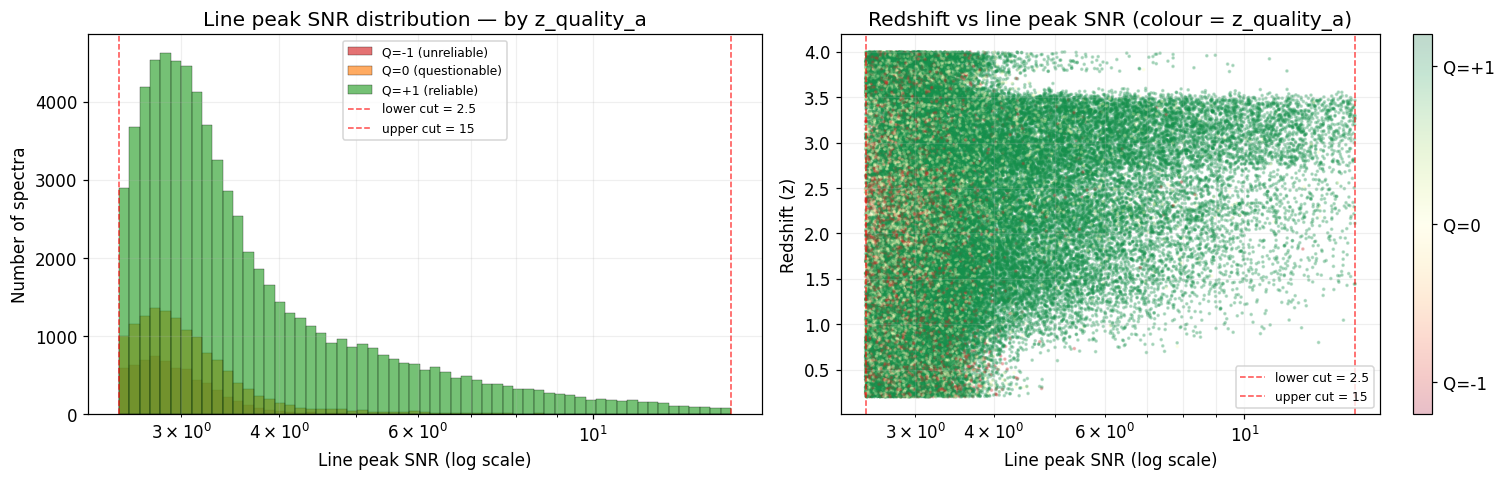

Line peak SNR summary stats:
count    92376.000000
mean         3.796223
std          1.753374
min          2.500009
1%           2.517277
5%           2.579453
50%          3.166922
95%          7.496472
99%         11.600939
max         14.994817
  N(line peak SNR >=  1.0):  92376 (100.0%)
  N(line peak SNR >=  2.5):  92376 (100.0%)
  N(line peak SNR >=  5.0):  13155 (14.2%)
  N(line peak SNR >= 10.0):   1783 (1.9%)
  N(line peak SNR >= 20.0):      0 (0.0%)
  N(line peak SNR >= 50.0):      0 (0.0%)
  N(line peak SNR >= 100.0):      0 (0.0%)

N(2.5 ≤ line_peak_snr ≤ 15): 92376 (100.0%)


In [8]:
lps = master_data['line_peak_snr']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel 1: Log-scale histogram of line peak SNR, coloured by quality
bins = np.logspace(np.log10(max(lps.min(), 0.05)), np.log10(lps.max()), 60)
for zq in zq_vals:
    sub = lps[master_data['z_quality_a'] == zq].dropna()
    axes[0].hist(sub, bins=bins, color=zq_colors[zq],
                 edgecolor='k', lw=0.3, alpha=0.65, label=zq_labels[zq])
axes[0].axvline(LINE_PEAK_SNR_MIN, color='r', ls='--', lw=1, alpha=0.7,
                label=f'lower cut = {LINE_PEAK_SNR_MIN}')
axes[0].axvline(LINE_PEAK_SNR_MAX, color='r', ls='--', lw=1, alpha=0.7,
                label=f'upper cut = {LINE_PEAK_SNR_MAX}')
axes[0].set_xscale('log')
axes[0].set_xlabel("Line peak SNR (log scale)")
axes[0].set_ylabel("Number of spectra")
axes[0].set_title("Line peak SNR distribution \u2014 by z_quality_a")
axes[0].legend(fontsize=8)
axes[0].grid(True, which='both', alpha=0.2)

# Panel 2: z vs line peak SNR scatter
sc = axes[1].scatter(
    lps, master_data['redshift'],
    s=2, alpha=0.25, c=master_data['z_quality_a'].fillna(0),
    cmap='RdYlGn', vmin=-1.2, vmax=1.2,
)
axes[1].axvline(LINE_PEAK_SNR_MIN, color='r', ls='--', lw=1, alpha=0.7,
                label=f'lower cut = {LINE_PEAK_SNR_MIN}')
axes[1].axvline(LINE_PEAK_SNR_MAX, color='r', ls='--', lw=1, alpha=0.7,
                label=f'upper cut = {LINE_PEAK_SNR_MAX}')
axes[1].set_xscale('log')
axes[1].set_xlabel("Line peak SNR (log scale)")
axes[1].set_ylabel("Redshift (z)")
axes[1].set_title("Redshift vs line peak SNR (colour = z_quality_a)")
axes[1].grid(True, which='both', alpha=0.2)
axes[1].legend(fontsize=8)
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['Q=-1', 'Q=0', 'Q=+1'])
plt.tight_layout()
plt.show()

print("Line peak SNR summary stats:")
print(lps.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_string())
for thr in [1.0, 2.5, 5.0, 10.0, 20.0, 50.0, 100.0]:
    n = (lps >= thr).sum()
    print(f"  N(line peak SNR >= {thr:>4.1f}): {n:>6d} ({100*n/len(lps):.1f}%)")

in_range = ((lps >= LINE_PEAK_SNR_MIN) & (lps <= LINE_PEAK_SNR_MAX)).sum()
print(f"\nN({LINE_PEAK_SNR_MIN} \u2264 line_peak_snr \u2264 {LINE_PEAK_SNR_MAX}): {in_range} ({100*in_range/len(lps):.1f}%)")


## 5. Sample spectra \u2014 high vs low line SNR

Three high-line-SNR (\u226512) and three low-line-SNR (\u22643) spectra. Each panel shows the
observed flux, the continuum model, and the continuum-subtracted flux.
The thresholds roughly bracket the quality-cut range 2.5\u201315.


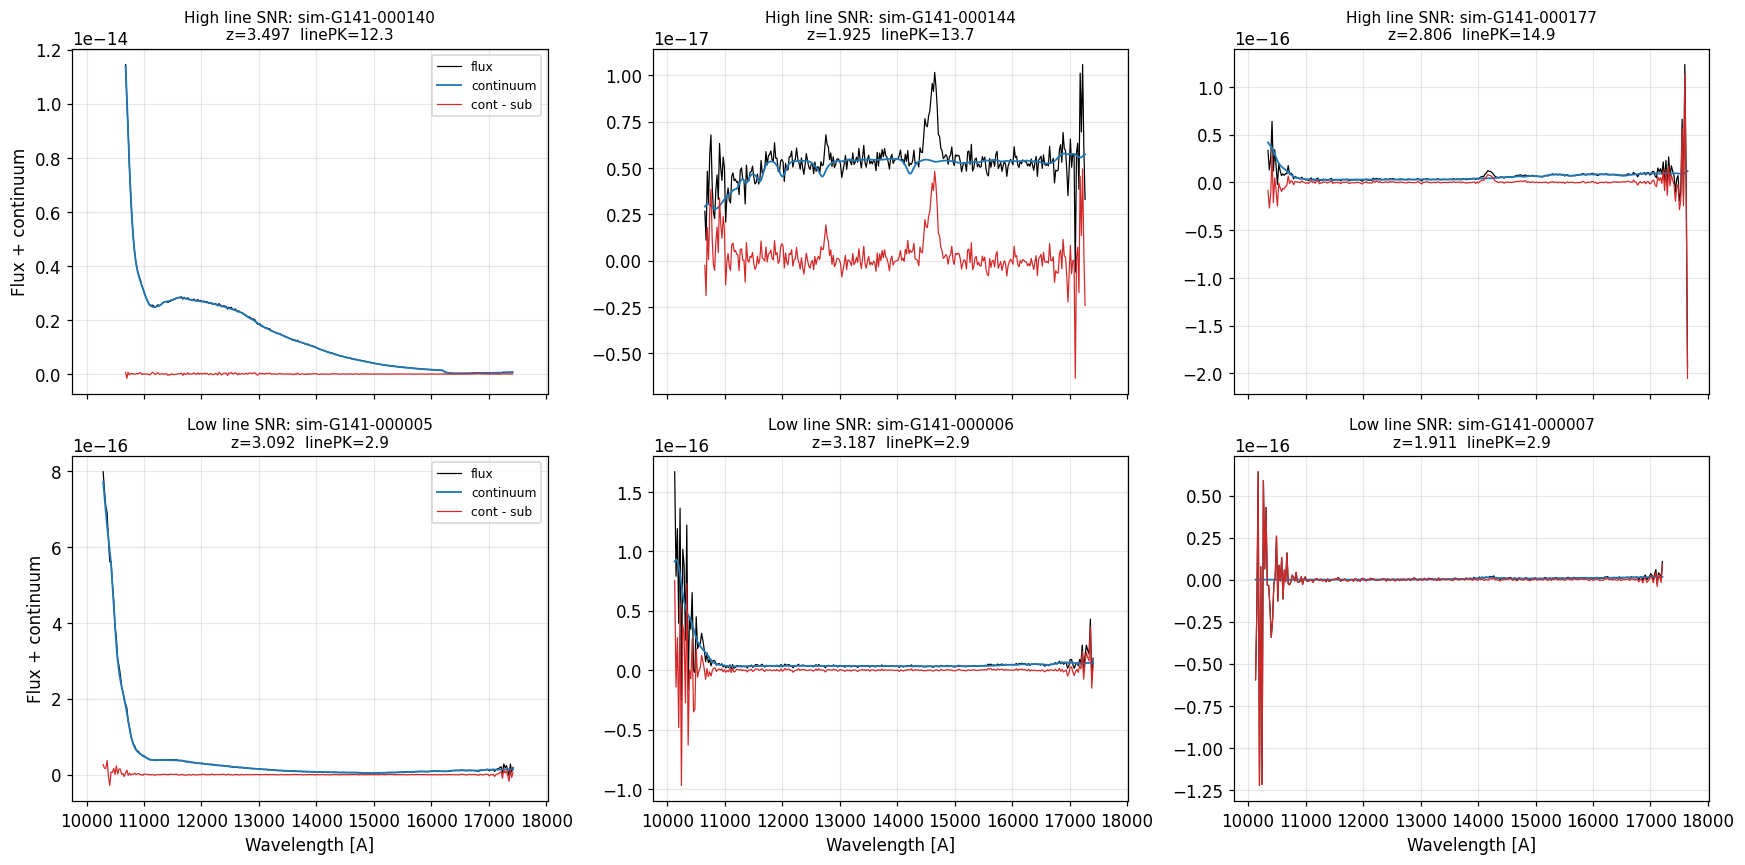

In [9]:
high_idx = master_data.index[
    (master_data['line_peak_snr'] >= 12)
].tolist()[:3]
low_idx  = master_data.index[
    (master_data['line_peak_snr'] <= 3)
].tolist()[:3]
# Fallback if <3 spectra match
if len(low_idx) < 3:
    low_idx = master_data.index[
        (master_data['line_peak_snr'] <= 4)
    ].tolist()[:3]
if len(high_idx) < 3:
    high_idx = master_data.index[
        (master_data['line_peak_snr'] >= 8)
    ].tolist()[:3]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for col, idxs, title_prefix in [
    (0, high_idx, "High line SNR"),
    (1, low_idx,  "Low line SNR"),
]:
    row_axes = axes[col]
    for j, i in enumerate(idxs):
        ax = row_axes[j]
        wl = np.asarray(master_data.loc[i, 'wave_a'])
        fl = np.asarray(master_data.loc[i, 'track_a_flam'])
        co = np.asarray(master_data.loc[i, 'track_a_cont'])
        z  = master_data.loc[i, 'redshift']
        lp = master_data.loc[i, 'line_peak_snr']
        gid = master_data.loc[i, 'grism_id']

        ax.plot(wl, fl, 'k', lw=0.8, label='flux')
        ax.plot(wl, co, 'C0', lw=1.2, label='continuum')
        ax.plot(wl, fl - co, 'C3', lw=0.8, label='cont - sub')
        ax.set_title(f"{title_prefix}: {gid}\nz={z:.3f}  linePK={lp:.1f}", fontsize=10)
        ax.grid(True, alpha=0.3)
        if j == 0:
            ax.legend(fontsize=8, loc='best')
        if col == 1:
            ax.set_xlabel("Wavelength [A]")
        if j == 0:
            ax.set_ylabel("Flux + continuum")
plt.tight_layout()
plt.show()


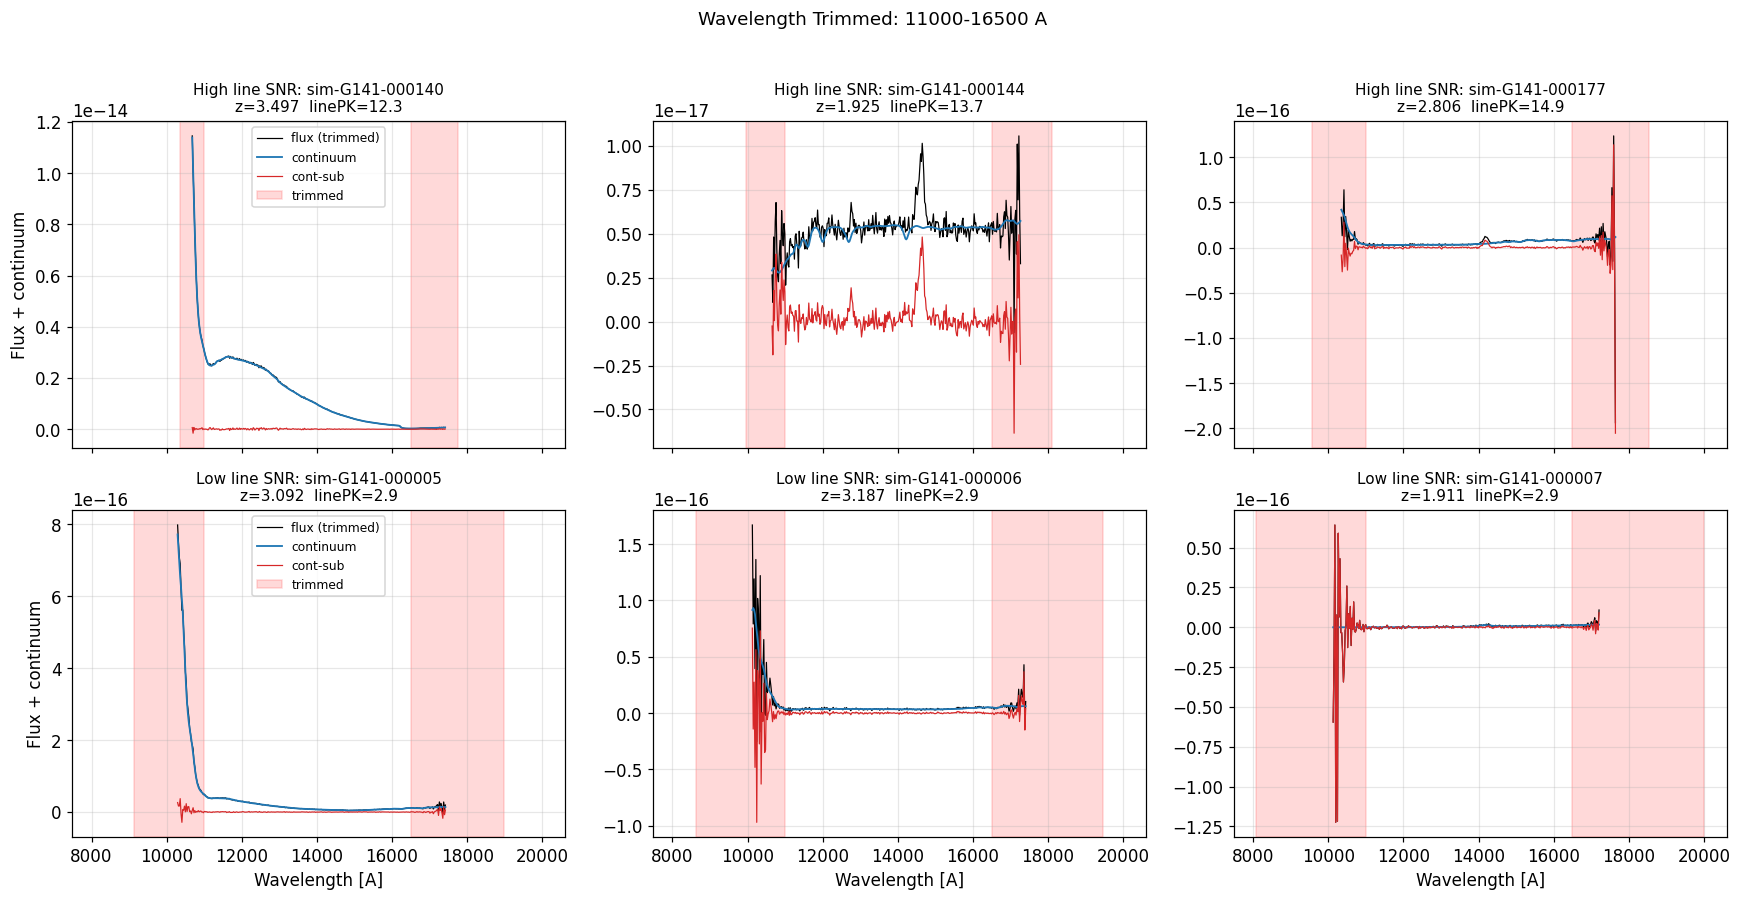

In [10]:
# Visualize the effect of wavelength trimming on the sample spectra
if WAVE_TRIM_ENABLED:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
    
    for col, idxs, title_prefix in [
        (0, high_idx, "High line SNR"),
        (1, low_idx,  "Low line SNR"),
    ]:
        row_axes = axes[col]
        for j, i in enumerate(idxs):
            ax = row_axes[j]
            wl = np.asarray(master_data.loc[i, 'wave_a'])
            fl = np.asarray(master_data.loc[i, 'track_a_flam'])
            co = np.asarray(master_data.loc[i, 'track_a_cont'])
            z  = master_data.loc[i, 'redshift']
            lp = master_data.loc[i, 'line_peak_snr']
            gid = master_data.loc[i, 'grism_id']

            # Plot valid (non-NaN) data
            valid = ~np.isnan(fl)
            if valid.any():
                ax.plot(wl[valid], fl[valid], 'k', lw=0.8, label='flux (trimmed)')
                ax.plot(wl[valid], co[valid], 'C0', lw=1.2, label='continuum')
                ax.plot(wl[valid], fl[valid] - co[valid], 'C3', lw=0.8, label='cont-sub')
            
            # Show trimmed regions as shaded
            xlim = ax.get_xlim()
            ax.axvspan(xlim[0], WAVE_MIN, alpha=0.15, color='red', label='trimmed' if j == 0 else '')
            ax.axvspan(WAVE_MAX, xlim[1], alpha=0.15, color='red')
            
            ax.set_title(f"{title_prefix}: {gid}\nz={z:.3f}  linePK={lp:.1f}", fontsize=10)
            ax.grid(True, alpha=0.3)
            if j == 0:
                ax.legend(fontsize=8, loc='best')
            if col == 1:
                ax.set_xlabel("Wavelength [A]")
            if j == 0:
                ax.set_ylabel("Flux + continuum")
    
    plt.suptitle(f"Wavelength Trimmed: {WAVE_MIN}-{WAVE_MAX} A", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Wavelength trimming disabled - skipping visualization.")


## 6. Interpolation to a uniform 7781-pixel grid

Each spectrum has its own native wavelength array. We resample all of them onto a
common grid of `N_PIXELS = 7781` points spanning `[mean(first_pixel), mean(last_pixel)]`
— that grid is wide enough to cover every native spectrum with the same uniform spacing.

Both the raw flux and the continuum-subtracted flux are interpolated. Out-of-range
pixels are filled with NaN (safe for masked regions).

If `WAVE_TRIM_ENABLED` is True, spectra are first trimmed to the reliable G141 range
(11000-16500 A) before interpolation to remove noisy detector edges.


In [16]:
wave_a = master_data['wave_a'].to_numpy()
first_elements = np.array([np.asarray(w)[0]  for w in wave_a])
last_elements  = np.array([np.asarray(w)[-1] for w in wave_a])

print(f"first pixel: min={first_elements.min():.1f}  median={np.median(first_elements):.1f}  max={first_elements.max():.1f}")
print(f"last  pixel: min={last_elements.min():.1f}  median={np.median(last_elements):.1f}  max={last_elements.max():.1f}")

new_wavelengths = np.linspace(np.mean(first_elements), np.mean(last_elements), N_PIXELS)
print(f"\nnew_wavelengths: start={new_wavelengths[0]:.1f}  end={new_wavelengths[-1]:.1f}  step={new_wavelengths[1]-new_wavelengths[0]:.4f} A")

# Apply wavelength trimming to native spectra before interpolation
# if WAVE_TRIM_ENABLED:
#     print(f"\nApplying wavelength trimming: {WAVE_MIN}-{WAVE_MAX} A")
#     n_trimmed = 0
#     for i in range(len(master_data)):
#         wl = np.asarray(master_data.iloc[i]['wave_a'])
#         master_data.iloc[i]['track_a_flam'] = trim_wavelength_range(
#             wl, master_data.iloc[i]['track_a_flam'], WAVE_MIN, WAVE_MAX
#         )
#         master_data.iloc[i]['track_a_cont'] = trim_wavelength_range(
#             wl, master_data.iloc[i]['track_a_cont'], WAVE_MIN, WAVE_MAX
#         )
#         n_trimmed += 1
#     print(f"Trimmed {n_trimmed} spectra")

n = len(master_data)
adjusted_flux   = [None] * n
adjusted_wl     = [None] * n
adjusted_cont_sub = [None] * n

for i in tqdm(range(n), desc="Interpolating"):
    wl = np.asarray(wave_a[i], dtype=float)
    fl = np.asarray(master_data.iloc[i]['track_a_flam'], dtype=float)
    co = np.asarray(master_data.iloc[i]['track_a_cont'], dtype=float)

    flux_interp = interp1d(wl, fl, kind='linear',
                            bounds_error=False, fill_value=np.nan)
    cont_sub_interp = interp1d(wl, fl - co, kind='linear',
                                bounds_error=False, fill_value=np.nan)

    adjusted_flux[i]     = flux_interp(new_wavelengths)
    adjusted_cont_sub[i] = cont_sub_interp(new_wavelengths)
    adjusted_wl[i]       = new_wavelengths

if WAVE_TRIM_ENABLED:
    print(f"Trimming to {WAVE_MIN}-{WAVE_MAX} A after interpolation")
    trim_mask = (new_wavelengths < WAVE_MIN) | (new_wavelengths > WAVE_MAX)
    for i in range(n):
        adjusted_flux[i][trim_mask] = np.nan
        adjusted_cont_sub[i][trim_mask] = np.nan

print(f"\nDone. adjusted_flux[0] shape: {adjusted_flux[0].shape}")


first pixel: min=9567.7  median=10311.6  max=11169.9
last  pixel: min=16677.7  median=17464.7  max=18253.4

new_wavelengths: start=10311.8  end=17464.4  step=0.9189 A


Interpolating: 100%|██████████| 92376/92376 [01:23<00:00, 1102.39it/s]


Trimming to 11000-16500 A after interpolation

Done. adjusted_flux[0] shape: (7781,)


## 7. Save wide-format training DataFrame as pickle

One row per spectrum — columns match what the dataloader expects:
`grism_id, z, SNR, spec, clean_flux_resampled`.

`spec` = interpolated `flam` (already sensitivity-corrected, erg/s/cm²/Å).
`SNR` = line_peak_snr (peak emission-line S/N).


In [17]:
import pickle

n = len(master_data)

wide_df = pd.DataFrame({
    'grism_id':           master_data['grism_id'].values,
    'z':                  master_data['redshift'].values.astype(np.float32),
    'SNR':                master_data['line_peak_snr'].values.astype(np.float32),
    'spec':               [adjusted_flux[i].astype(np.float32) for i in range(n)],
    'clean_flux_resampled': [adjusted_flux[i].astype(np.float32) for i in range(n)],
})

with open(str(OUT), 'wb') as f:
    pickle.dump(wide_df, f, protocol=pickle.HIGHEST_PROTOCOL)

size_mb = OUT.stat().st_size / 1e6
print(f'Wrote {len(wide_df):,} spectra -> {OUT}')
print(f'File size: {size_mb:.1f} MB')
print(f'Columns: {list(wide_df.columns)}')
spec0 = wide_df['spec'].iloc[0]
print(f'Spectrum dtype: {spec0.dtype}, shape: {spec0.shape}')


Wrote 92,376 spectra -> F:\personal_projects\specpt-hst-sim\data\training_format\grism_training_sim_v1.pkl
File size: 5758.4 MB
Columns: ['grism_id', 'z', 'SNR', 'spec', 'clean_flux_resampled']
Spectrum dtype: float32, shape: (7781,)


In [18]:
# Quick sanity: verify schema and spectrum shape
reloaded = pd.read_pickle(OUT)
expected_cols = ['grism_id', 'z', 'SNR', 'spec', 'clean_flux_resampled']
assert list(reloaded.columns) == expected_cols, f"Bad columns: {list(reloaded.columns)}"

n_spec = len(reloaded)
spec_shape = reloaded['spec'].iloc[0].shape
snr_range = (reloaded['SNR'].min(), reloaded['SNR'].max())
z_range = (reloaded['z'].min(), reloaded['z'].max())

assert spec_shape == (N_PIXELS,), f"Bad spectrum shape: {spec_shape}"
print(f"Loaded {n_spec:,} spectra")
print(f"Columns: {list(reloaded.columns)}")
print(f"Spectrum shape: {spec_shape}")
print(f"Z range: {z_range[0]:.3f} -> {z_range[1]:.3f}")
print(f"SNR range: {snr_range[0]:.2f} -> {snr_range[1]:.2f}")
print(f"Wavelength trim check OK: {WAVE_MIN}-{WAVE_MAX} A")
print("\nAll sanity checks passed.")


Loaded 92,376 spectra
Columns: ['grism_id', 'z', 'SNR', 'spec', 'clean_flux_resampled']
Spectrum shape: (7781,)
Z range: 0.200 -> 4.000
SNR range: 2.50 -> 14.99
Wavelength trim check OK: 11000-16500 A

All sanity checks passed.


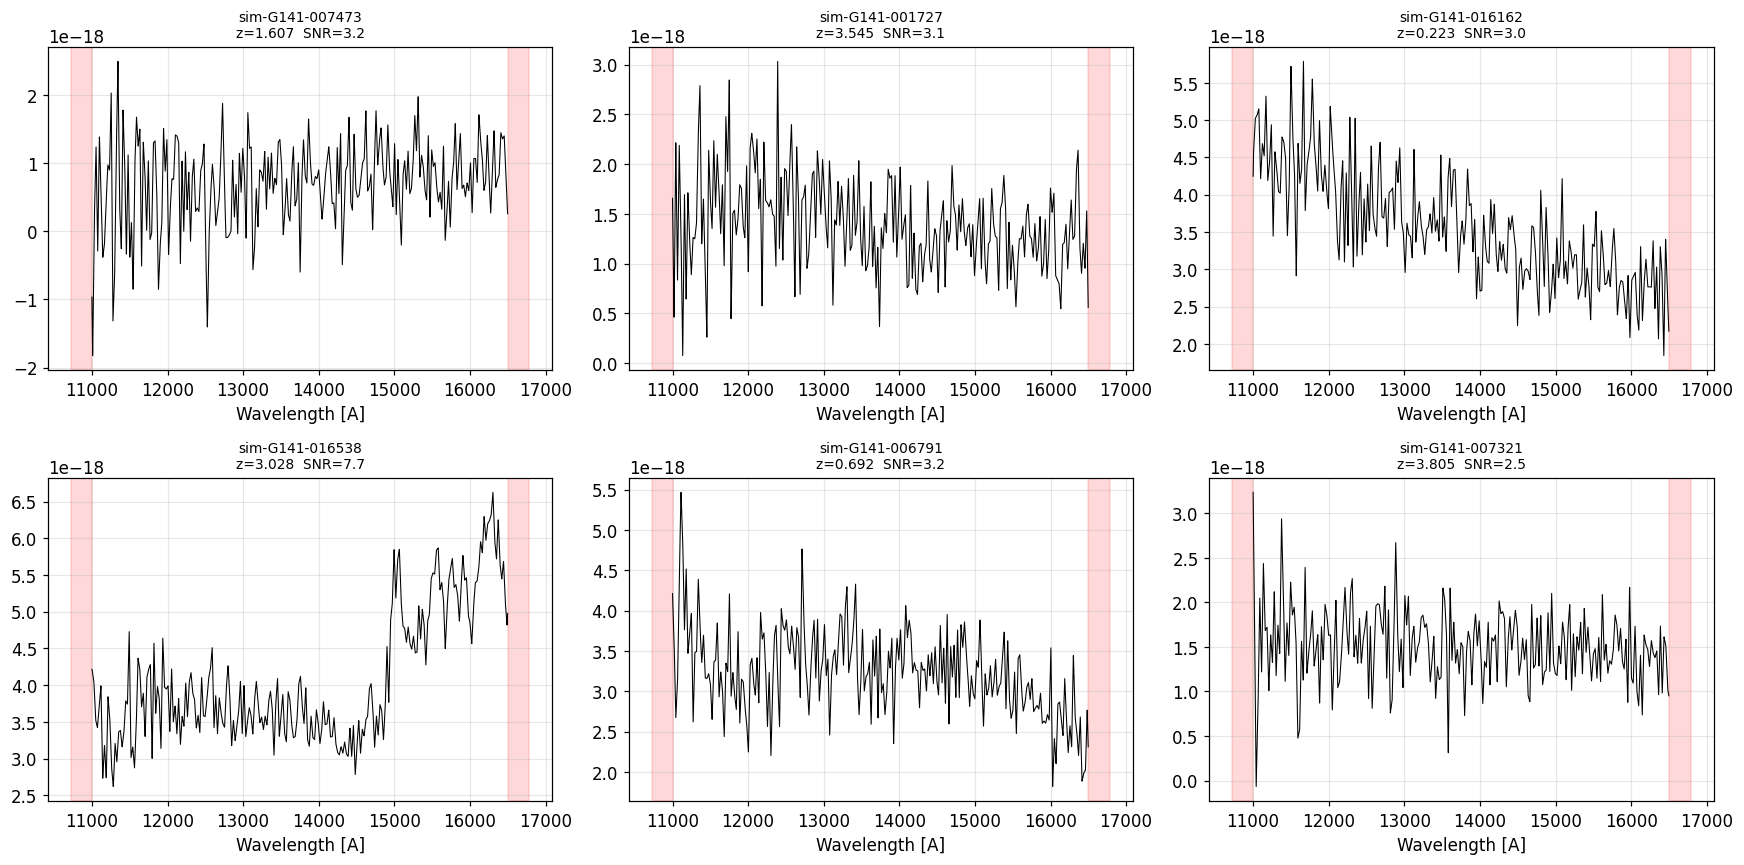

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Show 3 spectra with different SNR levels
sample = wide_df.sample(6, random_state=42)
new_wl = np.linspace(10311, 17464, N_PIXELS)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    flux = row['spec'].astype(np.float32)
    valid = ~np.isnan(flux)
    ax.plot(new_wl[valid], flux[valid], 'k', lw=0.7)
    if WAVE_TRIM_ENABLED:
        ax.axvspan(ax.get_xlim()[0], WAVE_MIN, alpha=0.15, color='red', label='trimmed')
        ax.axvspan(WAVE_MAX, ax.get_xlim()[1], alpha=0.15, color='red')
    ax.set_title(f"{row['grism_id']}\nz={row['z']:.3f}  SNR={row['SNR']:.1f}", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Wavelength [A]')

plt.tight_layout()
plt.show()